Total Unique Patients: 1000
Duplicate IDs found: 0
           mode  pain_score_baseline  discontinuation  patient_id
0   Closed-Loop                    4         0.119565          92
1   Closed-Loop                    5         0.195122          82
2   Closed-Loop                    6         0.227848          79
3   Closed-Loop                    7         0.169492          59
4   Closed-Loop                    8         0.220930          86
5   Closed-Loop                    9         0.228261          92
6        Manual                    4         0.302326          86
7        Manual                    5         0.302326          86
8        Manual                    6         0.336842          95
9        Manual                    7         0.310811          74
10       Manual                    8         0.263736          91
11       Manual                    9         0.320513          78


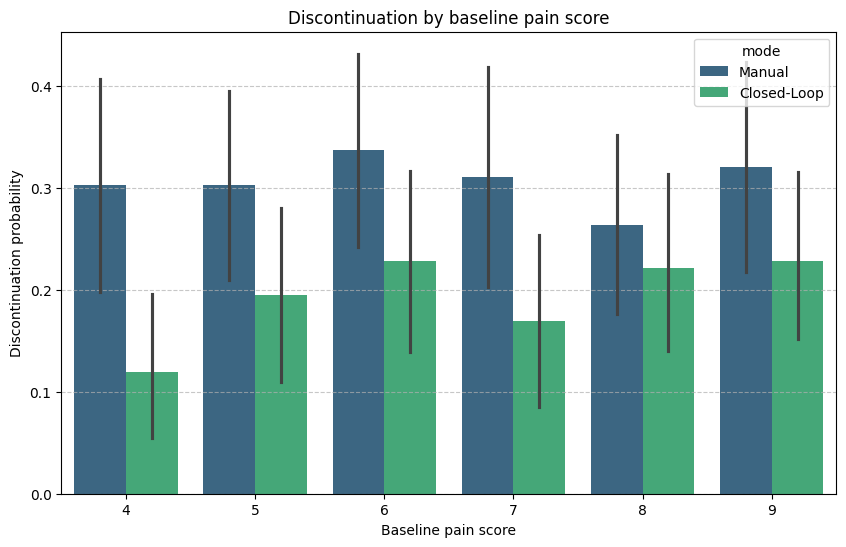

Total Estimated TVaR: $502,000.00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_patients = 1000

df = pd.DataFrame({
    'patient_id': [f"P_{i:04d}" for i in range(n_patients)],
    'mode': np.random.choice(['Closed-Loop', 'Manual'], n_patients),
    'pain_score_baseline': np.random.randint(4, 10, n_patients),
    'device_stability_score': np.random.uniform(1, 10, n_patients),
    'adherence_hours': np.random.normal(12, 3, n_patients)
})

df.loc[df['mode'] == 'Closed-Loop', 'adherence_hours'] += 3
df['discontinuation'] = (df['adherence_hours'] < 9) | (df['device_stability_score'] < 2.5)

print(f"Total Unique Patients: {df['patient_id'].nunique()}")
print(f"Duplicate IDs found: {df.duplicated(subset=['patient_id']).sum()}")

analysis_df = df.groupby(['mode', 'pain_score_baseline']).agg({
    'discontinuation': 'mean',
    'patient_id': 'count'
}).reset_index()
print(analysis_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='pain_score_baseline', y='discontinuation', hue='mode', data=df, palette='viridis')
plt.title('Discontinuation by baseline pain score')
plt.ylabel('Discontinuation probability')
plt.xlabel('Baseline pain score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

df['risk_value'] = df['discontinuation'] * 2000
total_risk = df['risk_value'].sum()
print(f"Total Estimated TVaR: ${total_risk:,.2f}")